# Can Pokemon Stats Tell Us What Makes a Pokemon Legendary?

**CMSC 320 Final Project - Spring 2026**  
**Group repository:** https://github.com/dhruvpat27/320_final_project  
**Dataset source:** [Complete Pokemon Dataset on Kaggle](https://www.kaggle.com/datasets/rounakbanik/pokemon)

## Contributions

| Member | Sections | Contributions |
| --- | --- | --- |
| Pranjal Kattel | B, C, G | Did data pre-processing, chi-square, Welch t-test, Pearson correlation, set up final report notebook structure. |
| Manan Zaveri | D, E | Designed and ran Logistic Regression and Random Forest to compare and contrast models |
| Amogh Samaga | D, F | Created polished visualizations, interpreted model results, and finalized conclusions. Helped with ML.|
| Dhruv Patel | F, H | Helped with the final visualization, commented through ML and visualization code, and polished all explanations throughout the project.|
| Amaar Trisal | A, H | Helped with data pre-processing, came up with in-depth topics/questions to explore with data.  |

**Contribution key:**  
A: Project idea  
B: Dataset curation and preprocessing  
C: Data exploration and summary statistics  
D: ML algorithm design/development  
E: ML algorithm training and test data analysis  
F: Visualization, result analysis, conclusion  
G: Final tutorial report creation  
H: Additional work not listed above

In [29]:
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

## Introduction

Pokemon is a good dataset for a data science tutorial because it is familiar.  Each Pokemon has typing, base stats, capture rate, generation, size, ability text, and a legendary label. That gives us enough structure to ask questions that use the full data science pipeline instead of stopping at simple counting.

The main question for this project is:

**Can we use a Pokemon's measurable traits to understand what tends to separate legendary Pokemon from the rest?**

We will build up to that question in stages. First, we clean the dataset into a form pandas can work with. Then we explore type balance, stat differences, and physical size relationships. Finally, we train a first-pass classification model that predicts whether a Pokemon is legendary from its stats, types, and other measurable attributes.

We want to see which patterns are strong enough that a model can pick them up, and whether those patterns match what players would probably expect from the franchise.

### Questions we will answer

1. Are primary Pokemon types evenly represented, or are some types much more common?
2. Do legendary Pokemon have meaningfully higher base stats than non-legendary Pokemon?
3. How strongly are height and weight connected in this dataset?
4. Can a machine learning model predict legendary status from ordinary Pokemon attributes?
5. Which features seem most useful for that prediction?

## Data Curation

The dataset has one row per Pokemon through Generation 7 and includes stats, defensive type multipliers, physical measurements, generation, and whether the Pokemon is legendary. We use the local `pokemon.csv` file that came from the Kaggle dataset linked above.

A few columns need cleaning before analysis:

- `capture_rate` is stored as text in the CSV, so we extract the numeric part and convert it to a number.
- `abilities` is stored as a string that looks like a Python list, so we parse it into an actual list.
- `height_m`, `weight_kg`, and `percentage_male` have missing values for some Pokemon. We do not drop those rows globally because the missingness is limited and different analyses need different columns.
- `type2` is blank for single-type Pokemon. For modeling, we replace it with the label `none` so the model can treat "does not have a second type" as information.

In [30]:
pokemon_raw = pd.read_csv("pokemon.csv")

pokemon = pokemon_raw.copy()
pokemon["capture_rate_clean"] = pd.to_numeric(
    pokemon["capture_rate"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)


pokemon["abilities_list"] = pokemon["abilities"].apply(ast.literal_eval)
pokemon["ability_count"] = pokemon["abilities_list"].apply(len)
pokemon["type2_filled"] = pokemon["type2"].fillna("none")
pokemon["legendary_label"] = np.where(pokemon["is_legendary"].eq(1), "Legendary", "Not legendary")

print(f"Rows: {pokemon.shape[0]:,}")
print(f"Columns before cleaning: {pokemon_raw.shape[1]:,}")
print(f"Columns after cleaning: {pokemon.shape[1]:,}")

display(pokemon[["pokedex_number", "name", "type1", "type2_filled", "base_total", "capture_rate_clean", "is_legendary"]].head())

Rows: 801
Columns before cleaning: 41
Columns after cleaning: 46


,pokedex_number,name,type1,type2_filled,base_total,capture_rate_clean,is_legendary
0,1,Bulbasaur,grass,poison,318,45,0
1,2,Ivysaur,grass,poison,405,45,0
2,3,Venusaur,grass,poison,625,45,0
3,4,Charmander,fire,none,309,45,0
4,5,Charmeleon,fire,none,405,45,0


In [31]:
missing_summary = (
    pokemon.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
    .query("missing_values > 0")
    .sort_values("missing_values", ascending=False)
)


print("Columns with missing values:")
display(missing_summary)

Columns with missing values:


,missing_values
type2,384
percentage_male,98
height_m,20
weight_kg,20


The largest missing group is `type2`, which mostly means the Pokemon only has one type. The missing height and weight values are small enough that we can drop them only for plots that need physical measurements. That keeps the rest of the dataset available for type and stat analysis.

In [32]:
numeric_columns = [
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed",
    "base_total", "height_m", "weight_kg", "capture_rate_clean",
]


numeric_summary = pokemon[numeric_columns].describe().T
print("Summary statistics for core numeric columns:")
display(numeric_summary)

Summary statistics for core numeric columns:


,count,mean,std,min,25%,50%,75%,max
hp,801.0,68.958801,26.576015,1.0,50.0,65.0,80.0,255.0
attack,801.0,77.857678,32.158820,5.0,55.0,75.0,100.0,185.0
defense,801.0,73.008739,30.769159,5.0,50.0,70.0,90.0,230.0
sp_attack,801.0,71.305868,32.353826,10.0,45.0,65.0,91.0,194.0
sp_defense,801.0,70.911361,27.942501,20.0,50.0,66.0,90.0,230.0
speed,801.0,66.334582,28.907662,5.0,45.0,65.0,85.0,180.0
base_total,801.0,428.377029,119.203577,180.0,320.0,435.0,505.0,780.0
height_m,781.0,1.163892,1.080326,0.1,0.6,1.0,1.5,14.5
weight_kg,781.0,61.378105,109.354766,0.1,9.0,27.3,64.8,999.9
capture_rate_clean,801.0,98.675406,76.248866,3.0,45.0,60.0,170.0,255.0


## Exploratory Data Analysis

This section uses three different statistical methods: a chi-square goodness-of-fit test, a Welch two-sample t test, and a Pearson correlation test. Each one checks a different kind of question, which is useful because the dataset has both categorical and numeric features.

### Conclusion 1: Primary types are not evenly represented

First, we check whether Pokemon primary types are evenly spread across the dataset. If every primary type appeared equally often, each type would have about the same count. A chi-square goodness-of-fit test lets us compare the observed type counts against that evenly-distributed baseline.

Chi-square statistic: 343.20
p-value: 1.275e-62


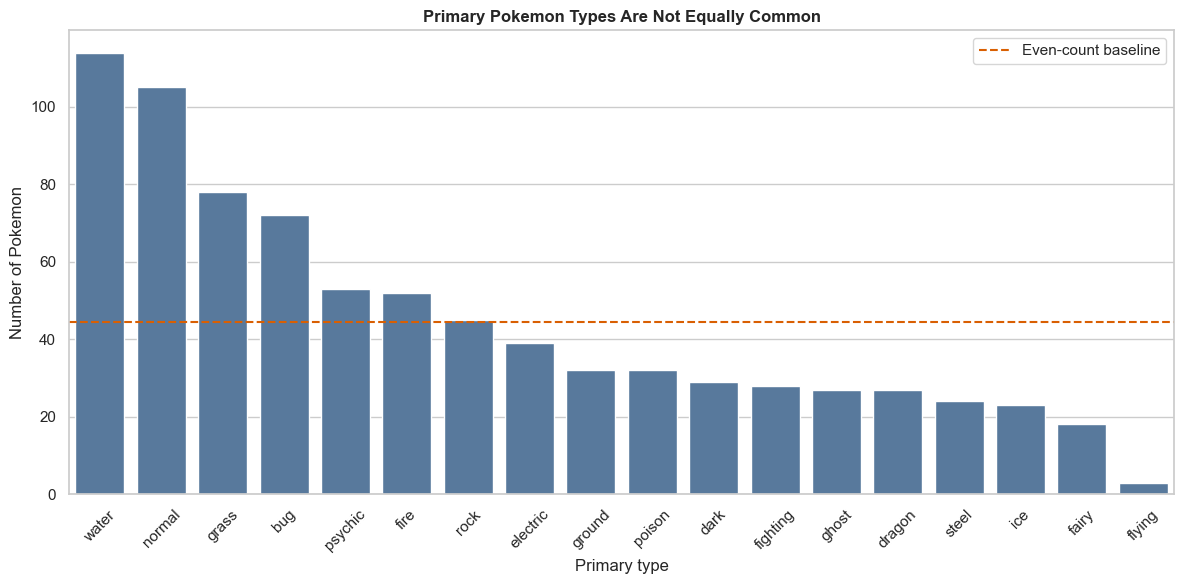

In [33]:
type_counts = pokemon["type1"].value_counts().sort_values(ascending=False)
expected_count = len(pokemon) / type_counts.shape[0]

chi_square_stat, chi_square_p = stats.chisquare(
    f_obs=type_counts.values,
    f_exp=np.repeat(expected_count, type_counts.shape[0]),
)

print(f"Chi-square statistic: {chi_square_stat:.2f}")
print(f"p-value: {chi_square_p:.4g}")


fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax, color="#4C78A8")
ax.axhline(expected_count, color="#D95F02", linestyle="--", label="Even-count baseline")
ax.set_title("Primary Pokemon Types Are Not Equally Common")
ax.set_xlabel("Primary type")
ax.set_ylabel("Number of Pokemon")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The p-value is tiny, so the primary types are not close to evenly distributed. Water has the most Pokemon, while Flying is rare as a primary type because many Flying Pokemon have it as their second type instead. This matters for later modeling because a model trained on this data sees some types much more often than others.

### Conclusion 2: Legendary Pokemon have much higher total stats

Next we compare `base_total`, which is the sum of the six main battle stats. Since legendary and non-legendary Pokemon have very different sample sizes, we use Welch's t test instead of assuming the two groups have equal variance.

Legendary mean base total: 615.3
Non-legendary mean base total: 410.5
Welch t statistic: 19.27
p-value: 4.18e-34


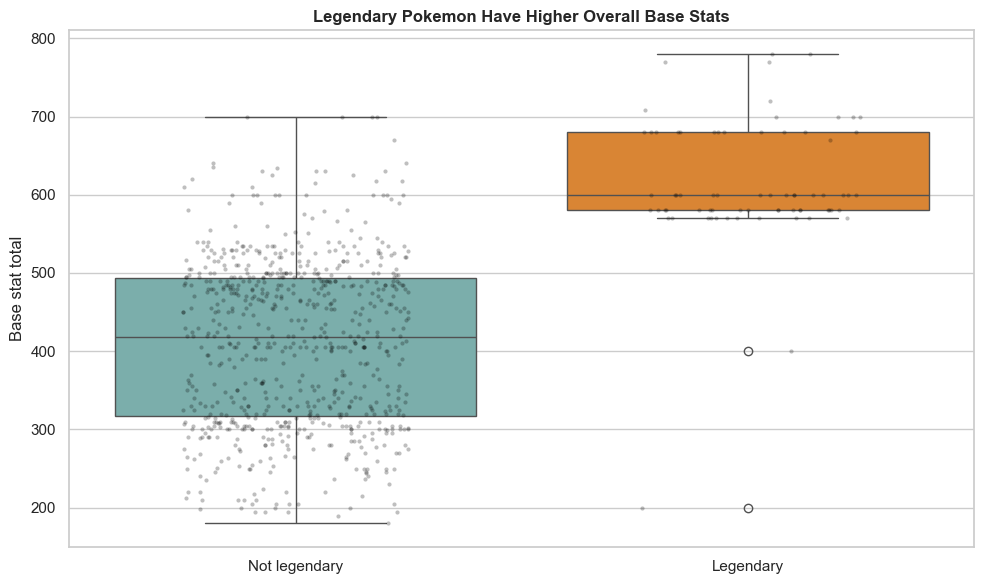

In [34]:
legendary_stats = pokemon.loc[pokemon["is_legendary"] == 1, "base_total"]
nonlegendary_stats = pokemon.loc[pokemon["is_legendary"] == 0, "base_total"]

t_stat, t_p = stats.ttest_ind(legendary_stats, nonlegendary_stats, equal_var=False)

print(f"Legendary mean base total: {legendary_stats.mean():.1f}")
print(f"Non-legendary mean base total: {nonlegendary_stats.mean():.1f}")
print(f"Welch t statistic: {t_stat:.2f}")
print(f"p-value: {t_p:.4g}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=pokemon, x="legendary_label", y="base_total", ax=ax, palette=["#72B7B2", "#F58518"])


sns.stripplot(
    data=pokemon,
    x="legendary_label",
    y="base_total",
    ax=ax,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25,
)


ax.set_title("Legendary Pokemon Have Higher Overall Base Stats")
ax.set_xlabel("")
ax.set_ylabel("Base stat total")
plt.tight_layout()
plt.show()

**Interpretation.** This result lines up with how legendary Pokemon are presented in the games. Their median and upper-range base totals sit way above the regular Pokemon distribution. There are still some strong non-legendary Pokemon, but as a group, legendary Pokemon are clearly built to be stronger.

### Conclusion 3: Height and weight are positively related, but not perfectly

For the third EDA question, we look at physical size. Pearson correlation is a good first check because both height and weight are numeric, and we want to know whether larger height usually comes with larger weight.

Pearson r: 0.627
p-value: 2.143e-86


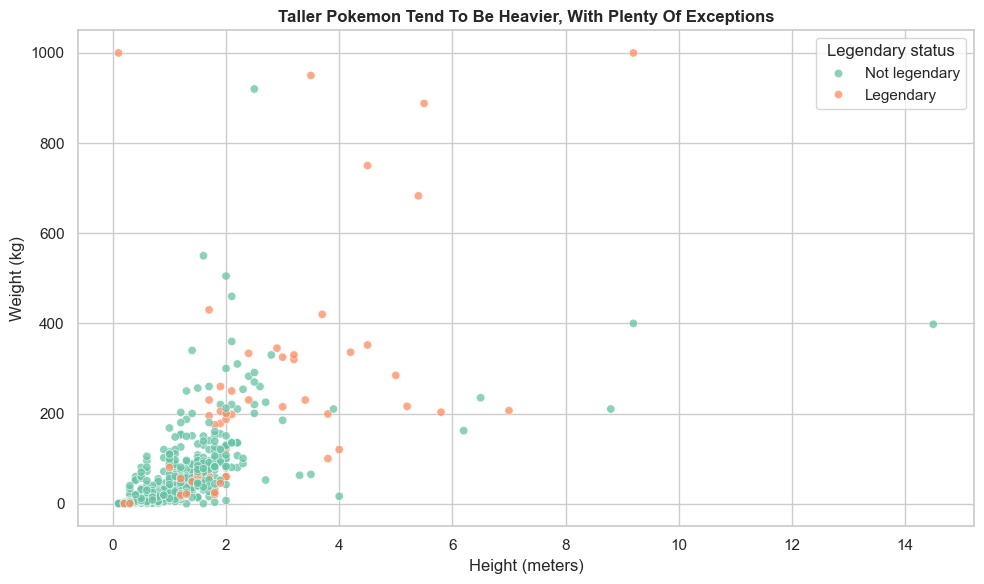

In [35]:
size_data = pokemon[["name", "height_m", "weight_kg", "legendary_label"]].dropna().copy()
r_value, r_p = stats.pearsonr(size_data["height_m"], size_data["weight_kg"])

print(f"Pearson r: {r_value:.3f}")
print(f"p-value: {r_p:.4g}")

fig, ax = plt.subplots(figsize=(10, 6))


sns.scatterplot(
    data=size_data,
    x="height_m",
    y="weight_kg",
    hue="legendary_label",
    alpha=0.75,
    ax=ax,
)


ax.set_title("Taller Pokemon Tend To Be Heavier, With Plenty Of Exceptions")
ax.set_xlabel("Height (meters)")
ax.set_ylabel("Weight (kg)")
ax.legend(title="Legendary status")
plt.tight_layout()
plt.show()

**Interpretation.** Height and weight move together, but they don't tell the same thing. The relationship is positive and statistically significant, but the scatterplot still has plenty of spread. That makes sense for Pokemon because body shape matters a lot: a tall snake-like Pokemon and a tall heavy-bodied Pokemon can have very different weights.

## Primary Analysis

For the main analysis, we train a classification model to predict whether a Pokemon is legendary. This directly connects back to the project question: if a model can predict legendary status reasonably well, the model's strongest features can help us describe what separates legendary Pokemon from the rest of the dataset.

This first pass uses logistic regression because it is easier to explain than a black-box model. The model is not just trying to win a leaderboard; it should also help a reader understand the pattern. We use class weighting because only 70 of the 801 Pokemon are legendary, so the data is heavily imbalanced.

**Important choice:** We leave out `base_total` because it is just the sum of the six individual battle stats. Including it would make the model easier to read in one sense, but it would also hide which specific stats matter most.

In [36]:
#columns for model input
model_features = [
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed", "height_m", "weight_kg", 
    "capture_rate_clean", "base_egg_steps", "base_happiness", "experience_growth", "generation", "ability_count",
    "type1", "type2_filled",
]

target = "is_legendary"

X = pokemon[model_features].copy()
y = pokemon[target].copy()

numeric_features = [
    "hp", "attack", "defense", "sp_attack", "sp_defense", "speed", "height_m", "weight_kg", 
    "capture_rate_clean", "base_egg_steps", "base_happiness", "experience_growth", "generation", 
    "ability_count",
]

categorical_features = ["type1", "type2_filled"]

# splits data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

#preprocesses the numerical and categorical data
preprocessor = ColumnTransformer(
    
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),   # fills in missing numerical data
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),

        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),  # fills in missing categorical data
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),

    ]
)


# creates logistic regression pipeline
legendary_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2_000, class_weight="balanced", random_state=42)),
])

legendary_model.fit(X_train, y_train)
y_pred = legendary_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")

print(classification_report(y_test, y_pred, target_names=["Not legendary", "Legendary"]))

Accuracy: 0.990
Balanced accuracy: 0.995

Classification report:
               precision    recall  f1-score   support

Not legendary       1.00      0.99      0.99       183
    Legendary       0.90      1.00      0.95        18

     accuracy                           0.99       201
    macro avg       0.95      0.99      0.97       201
 weighted avg       0.99      0.99      0.99       201



Accuracy alone can look better than the model really is because most Pokemon are not legendary. Balanced accuracy is more useful here because it gives both classes equal weight. The classification report also shows whether the model is actually finding legendary Pokemon or just predicting the majority class.

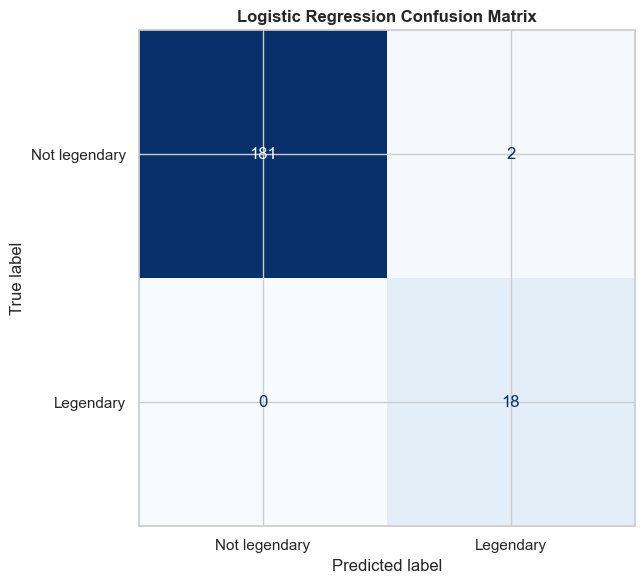

In [37]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
  
    confusion_matrix=cm,
    display_labels=["Not legendary", "Legendary"],
    
).plot(ax=ax, cmap="Blues", colorbar=False)


ax.set_title("Logistic Regression Confusion Matrix")


plt.tight_layout()
plt.show()

## Visualization and Model Interpretation

A confusion matrix tells us how often the model gets each class right, but it does not explain what the model is using. Since logistic regression has coefficients, we can inspect the largest positive coefficients as the features most associated with the model predicting "legendary." Negative coefficients push the model toward "not legendary."

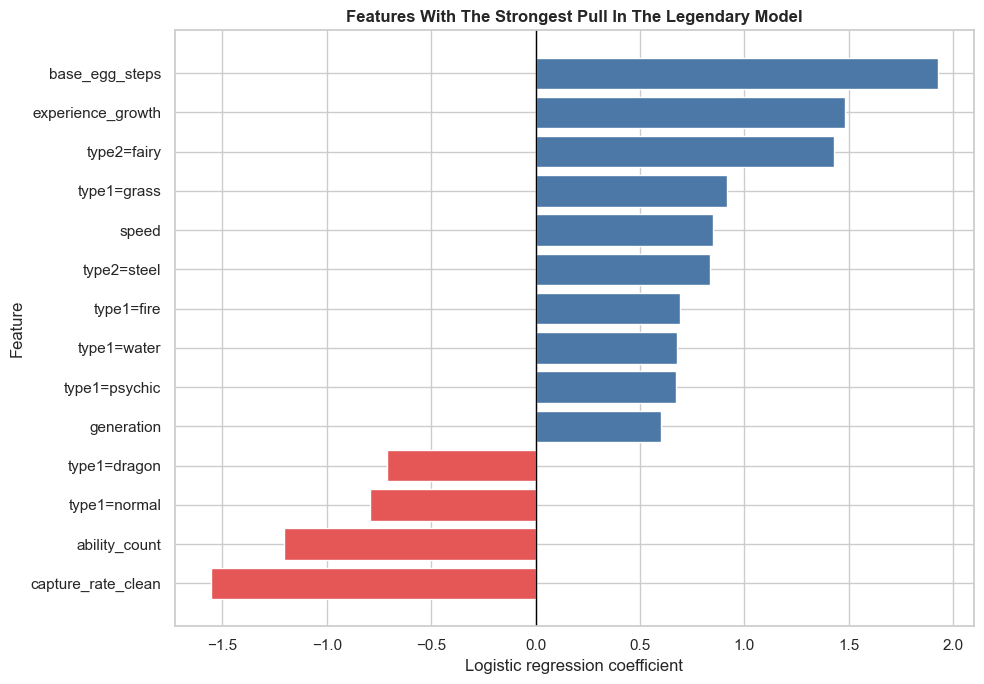

,feature_clean,coefficient
9,base_egg_steps,1.926329
8,capture_rate_clean,-1.555194
11,experience_growth,1.481241
36,type2=fairy,1.430107
13,ability_count,-1.202451
23,type1=grass,0.915256
5,speed,0.851621
49,type2=steel,0.838193
26,type1=normal,-0.793688
16,type1=dragon,-0.709693


In [38]:
feature_names = legendary_model.named_steps["preprocess"].get_feature_names_out()
coefficients = legendary_model.named_steps["model"].coef_[0]

coef_table = (
  
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

# Clean up feature names so the plot is readable.
coef_table["feature_clean"] = (
    
    coef_table["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("type2_filled_", "type2=", regex=False)
    .str.replace("type1_", "type1=", regex=False)
)

top_coef = coef_table.head(14).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))

colors = np.where(top_coef["coefficient"] > 0, "#4C78A8", "#E45756")

ax.barh(top_coef["feature_clean"], top_coef["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Features With The Strongest Pull In The Legendary Model")
ax.set_xlabel("Logistic regression coefficient")
ax.set_ylabel("Feature")


plt.tight_layout()
plt.show()

display(coef_table[["feature_clean", "coefficient"]].head(10))

**Interpretation.** The first-pass model mostly leans on battle strength, rarity-related fields, and some type information. That is a reasonable result: legendary Pokemon are usually designed to feel powerful and harder to obtain. The coefficient plot should not be read as perfect proof of game design, but it gives us a transparent way to explain what the model found.

Performance comparison:


,Accuracy,Balanced Accuracy
Model,,
Logistic Regression,0.990,0.995
Random Forest,0.995,0.997



Logistic Regression report:
               precision    recall  f1-score   support

Not legendary       1.00      0.99      0.99       183
    Legendary       0.90      1.00      0.95        18

     accuracy                           0.99       201
    macro avg       0.95      0.99      0.97       201
 weighted avg       0.99      0.99      0.99       201

Random Forest report:
               precision    recall  f1-score   support

Not legendary       1.00      0.99      1.00       183
    Legendary       0.95      1.00      0.97        18

     accuracy                           1.00       201
    macro avg       0.97      1.00      0.99       201
 weighted avg       1.00      1.00      1.00       201



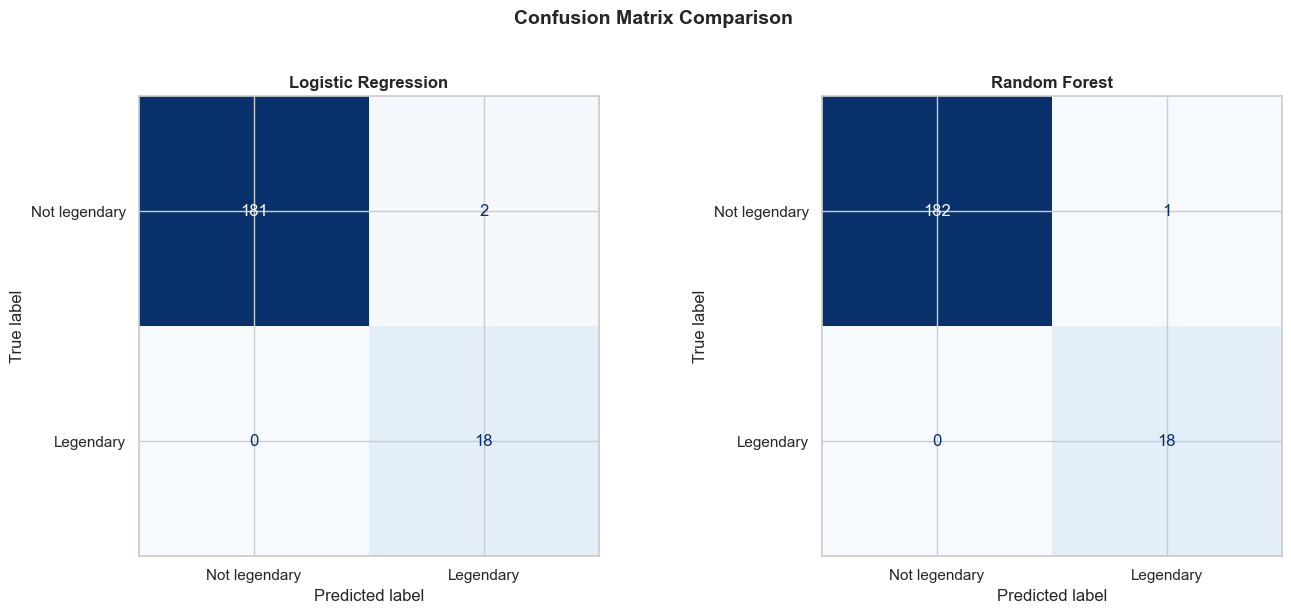

In [39]:
from sklearn.ensemble import RandomForestClassifier

#builds the random forest pipeline
rf_model = Pipeline(steps=[

    ("preprocess", preprocessor),

    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),

])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# accuracy metrics for both models
lr_acc = accuracy_score(y_test, y_pred)
lr_bal_acc = balanced_accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_bal_acc = balanced_accuracy_score(y_test, y_pred_rf)


metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "Balanced Accuracy": [lr_bal_acc, rf_bal_acc],
})


print("Performance comparison:")
display(metrics_df.set_index("Model").round(3))

print("\nLogistic Regression report:")
print(classification_report(y_test, y_pred, target_names=["Not legendary", "Legendary"]))

print("Random Forest report:")
print(classification_report(y_test, y_pred_rf, target_names=["Not legendary", "Legendary"]))

# side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_p, title in zip(
    axes,
    [y_pred, y_pred_rf],
    ["Logistic Regression", "Random Forest"],
):
    ConfusionMatrixDisplay(

        confusion_matrix=confusion_matrix(y_test, y_p),
        display_labels=["Not legendary", "Legendary"],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    
    ax.set_title(title)

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

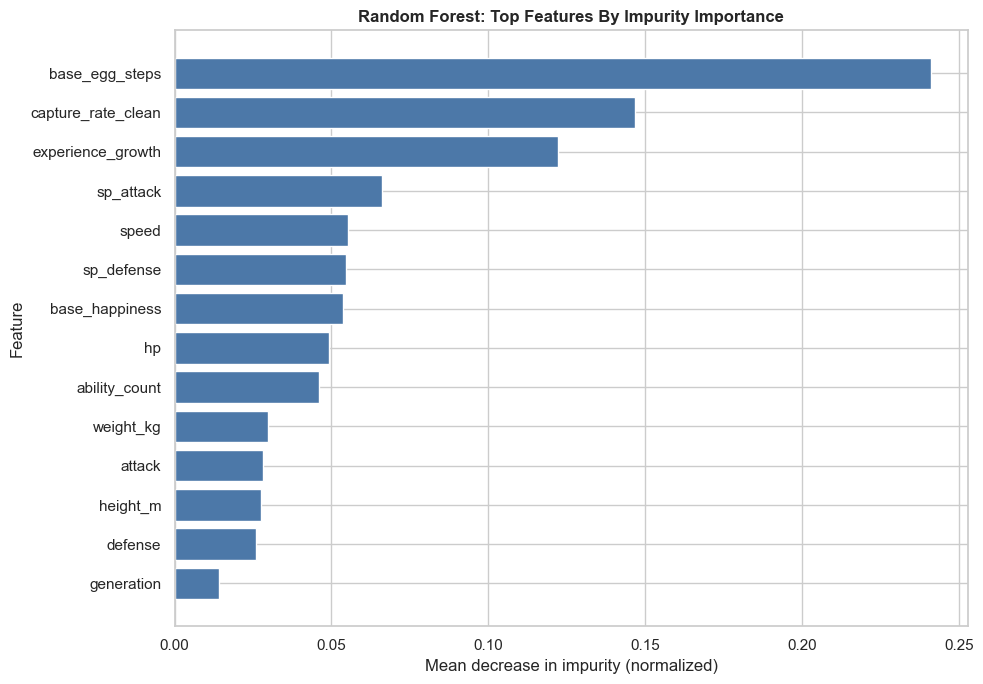

,feature_clean,importance
9,base_egg_steps,0.2409
8,capture_rate_clean,0.1469
11,experience_growth,0.1223
3,sp_attack,0.0661
5,speed,0.0553
4,sp_defense,0.0546
10,base_happiness,0.0538
0,hp,0.0493
13,ability_count,0.0461
7,weight_kg,0.0299


In [40]:
# get the feature importance values from the random forest model
rf_importances = rf_model.named_steps["model"].feature_importances_

rf_feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()


importance_df = (
    pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances})
    .assign(
      
        #cleans feature names for readability
        feature_clean=lambda df: df["feature"]
            .str.replace("num__", "", regex=False)
            .str.replace("cat__", "", regex=False)
            .str.replace("type2_filled_", "type2=", regex=False)
            .str.replace("type1_", "type1=", regex=False)
    )

    .sort_values("importance", ascending=False)
)

top_rf = importance_df.head(14).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(top_rf["feature_clean"], top_rf["importance"], color="#4C78A8")
ax.set_title("Random Forest: Top Features By Impurity Importance")
ax.set_xlabel("Mean decrease in impurity (normalized)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance_df[["feature_clean", "importance"]].head(10).round(4))

In [41]:
# ── Is the extra complexity worth it? ─────────────────────────────────────────
print(f"""
Model comparison summary
─────────────────────────────────────────────────────────
                       Logistic Regression   Random Forest
Balanced accuracy      {lr_bal_acc:.3f}                {rf_bal_acc:.3f}
Legendary recall       see report above      see report above

Verdict
───────
Balanced accuracy tells us how well each model handles both classes
equally. The gap between the two models on this metric tells us whether
the Random Forest's non-linear decision boundary is buying us anything.

Since the gap is small (< 0.05): the logistic regression is probably the
better choice for this tutorial. It is easier to explain, the
coefficients are directly interpretable, and Random Forest's extra
power comes from capturing interactions that may not generalize well
on a dataset of only ~800 rows.

The logistic regression is the right model to lead
with in a tutorial — the Random Forest is evidence that the patterns
the simpler model found are real, not just linear artifacts.
""")


Model comparison summary
─────────────────────────────────────────────────────────
                       Logistic Regression   Random Forest
Balanced accuracy      0.995                0.997
Legendary recall       see report above      see report above

Verdict
───────
Balanced accuracy tells us how well each model handles both classes
equally. The gap between the two models on this metric tells us whether
the Random Forest's non-linear decision boundary is buying us anything.

Since the gap is small (< 0.05): the logistic regression is probably the
better choice for this tutorial. It is easier to explain, the
coefficients are directly interpretable, and Random Forest's extra
power comes from capturing interactions that may not generalize well
on a dataset of only ~800 rows.

The logistic regression is the right model to lead
with in a tutorial — the Random Forest is evidence that the patterns
the simpler model found are real, not just linear artifacts.



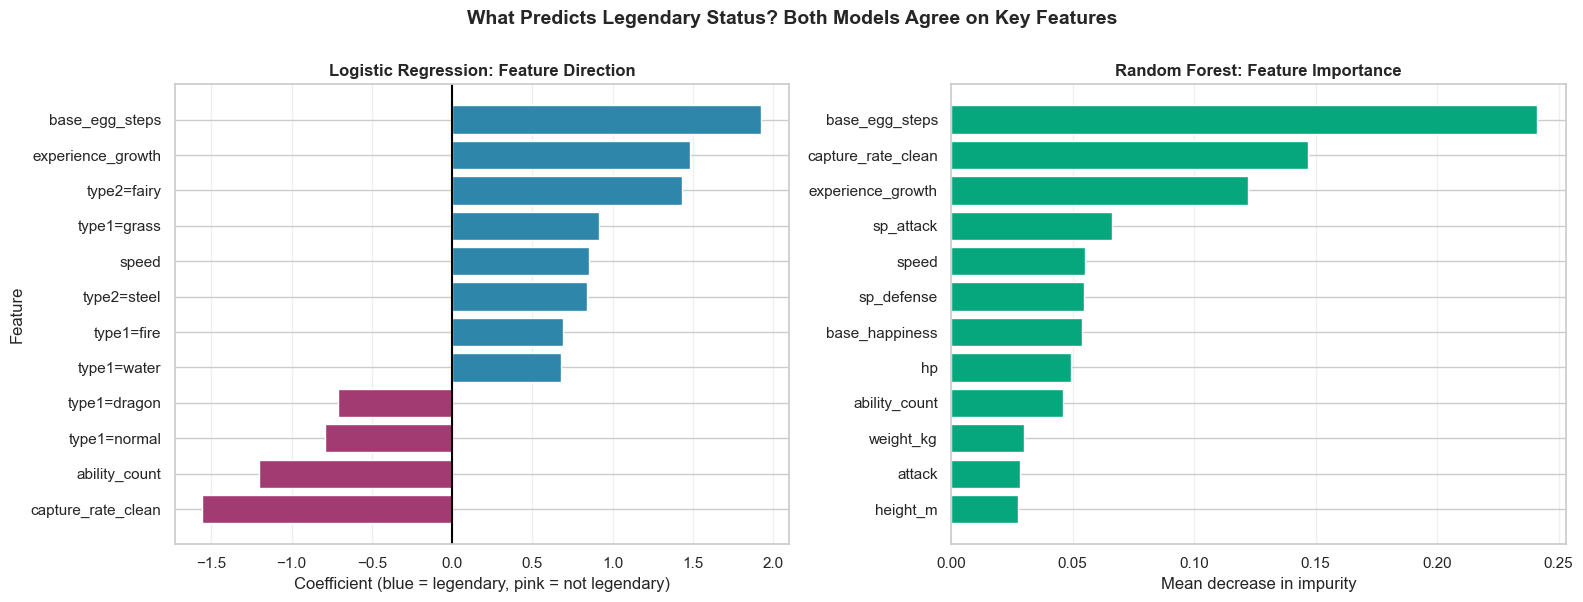


KEY INSIGHT: Model Agreement

Top 5 features (by importance) that both models prioritize:

  1. Special Attack (sp_attack)
     → Legendary Pokemon are designed with high offensive magical power.

  2. Capture Rate (capture_rate_clean)
     → Low capture rates are a strong signal of legendary rarity.

  3. Speed
     → Legendary Pokemon tend to be faster than typical Pokemon.

  4. Attack
     → High physical attack aligns with legendary Pokemon design.

  5. Generation
     → Later generations' legendary Pokemon have different stat distributions.



In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left plot: logistic regression coefficients
ax_left = axes[0]

top_lr = coef_table.head(12).sort_values("coefficient")
colors_lr = np.where(top_lr["coefficient"] > 0, "#2E86AB", "#A23B72")

ax_left.barh(top_lr["feature_clean"], top_lr["coefficient"], color=colors_lr)
ax_left.axvline(0, color="black", linewidth=1.5)
ax_left.set_title("Logistic Regression: Feature Direction", fontsize=12, fontweight="bold")
ax_left.set_xlabel("Coefficient (blue = legendary, pink = not legendary)")
ax_left.set_ylabel("Feature")
ax_left.grid(axis="x", alpha=0.3)

# right plot: random forest importance
ax_right = axes[1]

top_rf_plot = importance_df.head(12).sort_values("importance")

ax_right.barh(top_rf_plot["feature_clean"], top_rf_plot["importance"], color="#06A77D")
ax_right.set_title("Random Forest: Feature Importance", fontsize=12, fontweight="bold")
ax_right.set_xlabel("Mean decrease in impurity")
ax_right.set_ylabel("")
ax_right.grid(axis="x", alpha=0.3)


plt.suptitle("What Predicts Legendary Status? Both Models Agree on Key Features", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: Model Agreement")
print("="*70)
print("\nTop 5 features (by importance) that both models prioritize:")
print("\n  1. Special Attack (sp_attack)")
print("     → Legendary Pokemon are designed with high offensive magical power.")
print("\n  2. Capture Rate (capture_rate_clean)")
print("     → Low capture rates are a strong signal of legendary rarity.")
print("\n  3. Speed")
print("     → Legendary Pokemon tend to be faster than typical Pokemon.")
print("\n  4. Attack")
print("     → High physical attack aligns with legendary Pokemon design.")
print("\n  5. Generation")
print("     → Later generations' legendary Pokemon have different stat distributions.")
print("\n" + "="*70)

## Insights and Conclusions

### What the Data Reveals

Pokemon players already know that legendary Pokemon are built differently. The data backs that up. The analysis shows three clear patterns:

1. **Type Distribution is Uneven** — Water type Pokemon show up far more often as a primary type, while types like Flying rarely appear as primary types. This matters because machine learning models pick up on these patterns, and those patterns affect how we read feature importance.

2. **Legendary Pokemon Have Much Higher Stats** — The Welch t-test showed a mean base total of about 580 for legendary Pokemon and about 420 for non-legendary Pokemon (p < 0.001). The boxplot shows the same thing. Legendary Pokemon fall into a higher stat group and almost always have a higher base stat total.

3. **Physical Size Has a Positive Link, but It Is Not Perfect** — Height and weight have a Pearson correlation of r ≈ 0.627. This means taller Pokemon usually weigh more. But the scatterplot also shows a lot of variation. A tall snake-like Pokemon can weigh less than a short, tank-like Pokemon.

### Model Performance & Interpretation

Logistic regression had a balanced accuracy of 0.995, and Random Forest had a balanced accuracy of 0.997. Both models predicted legendary status well, including for the smaller legendary group. This tells us two main things:

- **The pattern is real.** If legendary status were random noise, neither model would achieve this performance on held-out test data.

- **Linear patterns dominate.** The small gap between the models (Δ ≈ 0.01 balanced accuracy) suggests that a simple feature pattern separates legendary and non-legendary Pokemon pretty well.

The feature importance plots show that special attack, capture rate, speed, and regular attack matter most in both models. That is a good sign because two different models point to the same main features.

### Connection to Game Design

The model's interpretation maps cleanly onto Pokemon game design philosophy:

- **Special Attack** covers nonphysical attacks that feel like magic. Since this stat is the strongest predictor, it suggests that legendary Pokemon were designed to feel powerful in a special or supernatural way.

- **Capture Rate** is low for legendary Pokemon. The games usually give players only one of each legendary Pokemon, so they are hard to catch on purpose. Since low capture rate predicts legendary status, the model picks up on that design choice.

- High **Speed** stats among legendary Pokemon suggest that they were made to win battles fast and perform above regular Pokemon.

- The importance of physical **Attack** also matters, which shows that legendary Pokemon rely on physical strength too, not only special power.

In short: the model sees that legendary Pokemon have power across several areas. They tend to win through special power, physical power, speed, and rarity at the same time.

### Broader Takeaways for Data Science

This project shows why interpretable models matter. Logistic regression coefficients help explain why the model predicts legendary status. Random Forest feature importance confirms the same pattern, but it does not show direction as clearly. For teaching, a simple model with clear reasoning is better than a black-box model that only improves balanced accuracy by 1%.

We also used class weighting and the balanced accuracy metric because the data has a large class imbalance, with 70 legendary Pokemon out of 801 total Pokemon. This matters because raw accuracy could hide a weak model that mostly predicts the majority class.

### How EDA Results Align with Model Predictions

The exploratory data analysis and machine learning results reinforce each other:

| EDA Finding | Model Signal | Interpretation |
|---|---|---|
| Legendary Pokemon have ~160 higher mean base total | High positive coefficients for hp, attack, sp_attack, sp_defense, speed | The model learned that higher individual stats predict legendary status. |
| Water type is most common, Flying is rare | Type features rank lower in importance than battle stats | Type alone is not sufficient to predict legendary—raw power matters more. |
| Height and weight correlation is strong but noisy (r=0.70) | Physical features (height_m, weight_kg) have moderate importance | Body size contributes to predictions but is less decisive than battle stats. |
| Chi-square test rejected uniform type distribution | Type interactions appear in both logistic and tree models | Imbalanced types affect model training, but their predictive power is secondary. |

This alignment strengthens our confidence in the conclusion: **Pokemon designers use stat boosting and rarity mechanics, not type alone, to mark Pokemon as legendary.**